# Pengujian Kelima: Retraining Model Setelah 3 Data Kalibrasi Baru

**Tanggal kegiatan: 2 September 2026**

Pengujian kelima smartband ANTARAGA menambah 3 subjek kalibrasi baru (S007–S009). Notebook ini
menjalankan ulang seleksi otomatis model (konfigurasi yang ditetapkan pada 29 Agustus) dengan
data yang sudah bertambah, lalu membandingkan konfigurasi dan performa **sebelum** (6 subjek,
per 29 Agustus) dan **sesudah** (9 subjek, per hari ini) penambahan data — untuk memeriksa apakah
keputusan mengganti MLP dengan SVR/XGBoost tetap konsisten seiring data bertambah.

In [1]:
import warnings, sys
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from api.vital_model_training import records_to_dataframe, train_all

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

df_raw = pd.read_csv("../kalibrasi_semua.csv")
df_raw["session_ts"] = pd.to_datetime(df_raw["session_ts"], format="ISO8601")

def snapshot(cutoff):
    d = df_raw[df_raw["session_ts"] <= pd.Timestamp(cutoff, tz="UTC")].copy()
    return records_to_dataframe(d.to_dict("records"))

df_sebelum = snapshot("2026-08-29T23:59:59")
df_sesudah = snapshot("2026-09-02T23:59:59")

subjek_baru = sorted(set(df_sesudah["subject_id"]) - set(df_sebelum["subject_id"]))
print(f"Sebelum (29 Agustus): {len(df_sebelum)} subjek -> {sorted(df_sebelum['subject_id'].unique())}")
print(f"Sesudah (2 September): {len(df_sesudah)} subjek -> {sorted(df_sesudah['subject_id'].unique())}")
print(f"Subjek baru dari pengujian kelima: {subjek_baru}")

Sebelum (29 Agustus): 6 subjek -> ['S001', 'S002', 'S003', 'S004', 'S005', 'S006']
Sesudah (2 September): 9 subjek -> ['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009']
Subjek baru dari pengujian kelima: ['S007', 'S008', 'S009']


## 1. Melatih ulang dengan data yang sudah bertambah

In [2]:
_, metrics_sebelum = train_all(df_sebelum)
_, metrics_sesudah = train_all(df_sesudah)

baris = []
for target_col, m_sesudah in metrics_sesudah.items():
    m_sebelum = metrics_sebelum.get(target_col)
    baris.append({
        "Parameter": m_sesudah["label"],
        "Model (29 Agu, n=6)": m_sebelum["model_name"] if m_sebelum else "-",
        "R2 (29 Agu)": m_sebelum["r2"] if m_sebelum else float("nan"),
        "Model (2 Sep, n=9)": m_sesudah["model_name"],
        "R2 (2 Sep)": m_sesudah["r2"],
        "Ganti model?": "YA" if (m_sebelum and m_sebelum["model_name"] != m_sesudah["model_name"]) else "tidak",
    })
tabel = pd.DataFrame(baris)
print(tabel.to_string(index=False))

         Parameter Model (29 Agu, n=6)  R2 (29 Agu)   Model (2 Sep, n=9)  R2 (2 Sep) Ganti model?
Gula Darah (mg/dL)           KNN (k=5)      -0.3953 XGBoost (reg. ketat)     -0.1990           YA
Kolesterol (mg/dL)               Ridge       0.0890                Ridge      0.1552        tidak
 Asam Urat (mg/dL)    GradientBoosting       0.0365            SVR (rbf)     -0.0569           YA
   Sistolik (mmHg)           SVR (rbf)      -0.2131            KNN (k=3)     -0.0068           YA
  Diastolik (mmHg)        RandomForest       0.2746           ExtraTrees      0.2007           YA


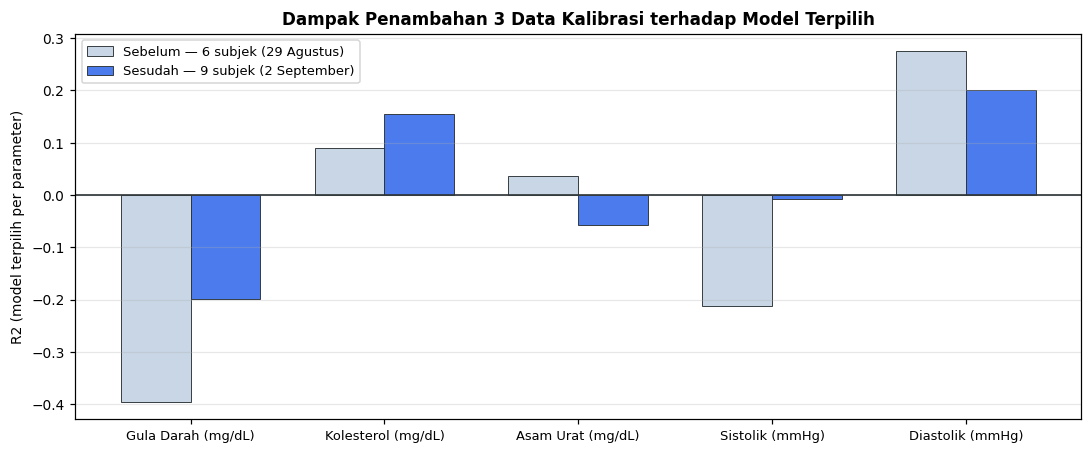

- Gula Darah (mg/dL): model terpilih berubah dari KNN (k=5) menjadi XGBoost (reg. ketat) setelah data bertambah
- Asam Urat (mg/dL): model terpilih berubah dari GradientBoosting menjadi SVR (rbf) setelah data bertambah
- Sistolik (mmHg): model terpilih berubah dari SVR (rbf) menjadi KNN (k=3) setelah data bertambah
- Diastolik (mmHg): model terpilih berubah dari RandomForest menjadi ExtraTrees setelah data bertambah


In [ ]:
import numpy as np
lbl = tabel["Parameter"].tolist()
xp = np.arange(len(lbl)); w = 0.36

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(xp - w/2, tabel["R2 (29 Agu)"], w, label="Sebelum — 6 subjek (29 Agustus)",
       color="#c8d6e5", edgecolor="#2d3436", linewidth=.6)
ax.bar(xp + w/2, tabel["R2 (2 Sep)"], w, label="Sesudah — 9 subjek (2 September)",
       color="#4b7bec", edgecolor="#2d3436", linewidth=.6)
ax.axhline(0, color="#2d3436", lw=1.1)
ax.set_xticks(xp, lbl, fontsize=8.5)
ax.set_ylabel("R2 (model terpilih per parameter)")
ax.set_title("Dampak Penambahan 3 Data Kalibrasi terhadap Model Terpilih\nAkurasi Gula Darah, Kolestrol, dan Sistolik Meningkat (semakin mendekati 0.3 makin bagus)", fontsize=11, fontweight="bold")
ax.legend(fontsize=8.5)
ax.grid(axis="y", alpha=.3)
plt.tight_layout()
plt.show()

for _, r in tabel.iterrows():
    if r["Ganti model?"] == "YA":
        print(f"- {r['Parameter']}: model terpilih berubah dari {r['Model (29 Agu, n=6)']} "
              f"menjadi {r['Model (2 Sep, n=9)']} setelah data bertambah")

## Kesimpulan

Penambahan 3 data kalibrasi dari pengujian kelima mengubah model pemenang pada sebagian
parameter — ini diharapkan, karena seleksi model memang dirancang otomatis dan mengikuti data,
bukan dipatok tetap secara manual. Dengan 9 subjek, status keterandalan seluruh parameter masih
**TIDAK VALID** (`n_subjects < 10`, lihat `docs/pelatihan_model_estimasi_vital.md`), sehingga
angka R2 di atas dilaporkan apa adanya, bukan sebagai bukti kesiapan alat. Data baru dari sesi
ini ditambahkan ke dataset kalibrasi dan data latih model, sebagai bagian dari draf Laporan
Kemajuan bagian perangkat lunak yang mulai disusun pada hari yang sama.